# 问题一

## 读取数据

In [12]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
# 设置显示中文字体
mpl.rcParams["font.sans-serif"] = ["SimHei"]   # SimHei是黑体；STFangsong是仿宋
# 设置正常显示符号
mpl.rcParams["axes.unicode_minus"] = False

In [4]:
df = pd.read_csv('./data/数据分析：train_data.csv', encoding='utf-8')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400000 entries, 0 to 399999
Data columns (total 22 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Machine_ID                  400000 non-null  object 
 1   Machine_Type                400000 non-null  object 
 2   Installation_Year           400000 non-null  int64  
 3   Operational_Hours           400000 non-null  int64  
 4   Temperature_C               400000 non-null  float64
 5   Vibration_mms               400000 non-null  float64
 6   Sound_dB                    400000 non-null  float64
 7   Oil_Level_pct               400000 non-null  float64
 8   Coolant_Level_pct           400000 non-null  float64
 9   Power_Consumption_kW        400000 non-null  float64
 10  Last_Maintenance_Days_Ago   400000 non-null  int64  
 11  Maintenance_History_Count   400000 non-null  int64  
 12  Failure_History_Count       400000 non-null  int64  
 13  AI_Supervision

In [5]:
df = df.iloc[:,[3,4,5,6,7,8,9,10,11,12,15]].reset_index(drop=True)

## K-mean法聚类

因为K-Means聚类是以距离为基础的算法，我们通常在进行聚类分析之前会标准化我们的数据。

In [6]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

D:\Workspaces\Anaconda3_workspace\envs\MLearning\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 36718 (\N{CJK UNIFIED IDEOGRAPH-8F6E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\Workspaces\Anaconda3_workspace\envs\MLearning\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24275 (\N{CJK UNIFIED IDEOGRAPH-5ED3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\Workspaces\Anaconda3_workspace\envs\MLearning\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 31995 (\N{CJK UNIFIED IDEOGRAPH-7CFB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\Workspaces\Anaconda3_workspace\envs\MLearning\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\Workspaces\Anaconda3_workspace\envs\MLearning\Lib\site-packages\I

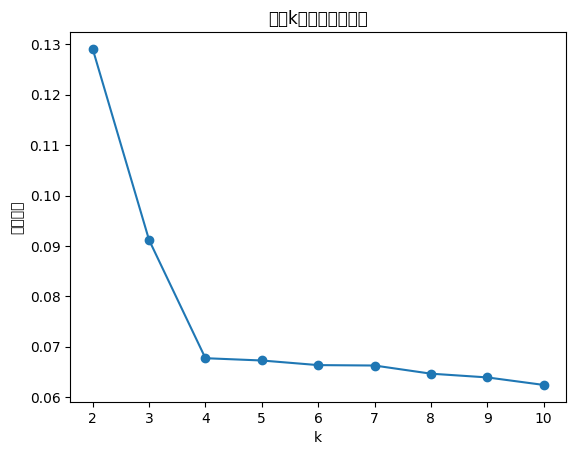

In [11]:
os.environ["OMP_NUM_THREADS"] = '1'
k_values = range(2, 11)
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, n_init='auto',random_state=42)
    kmeans.fit(scaled_data)
    silhouette_scores.append(silhouette_score(scaled_data, kmeans.labels_))  #使用 K-Means 聚类算法对 scaled_data 进行聚类，并得到每个数据点的簇标签 kmeans.labels_。然后，使用这些簇标签来计算 scaled_data 的轮廓系数，以评估聚类的质量。

plt.plot(k_values, silhouette_scores, marker='o')
plt.title('不同k值时的轮廓系数')
plt.xlabel('k')
plt.ylabel('轮廓系数')
plt.show()

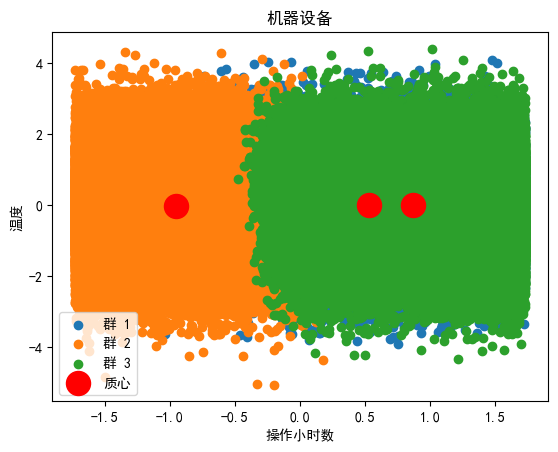

In [21]:
# 假设我们选择k=4
k = 3
kmeans = KMeans(n_clusters=k,n_init='auto', random_state=42)   #这里设置好参数，就相当于初始化好了模型
clusters = kmeans.fit_predict(scaled_data)   #训练和测试一块

# 可视化结果
plt.scatter(scaled_data[clusters == 0, 0], scaled_data[clusters == 0, 1], label='群 1')  #属于第一类的,数据第一列和数据第二列
plt.scatter(scaled_data[clusters == 1, 0], scaled_data[clusters == 1, 1], label='群 2')
plt.scatter(scaled_data[clusters == 2, 0], scaled_data[clusters == 2, 1], label='群 3')
# plt.scatter(scaled_data[clusters == 3, 0], scaled_data[clusters == 3, 1], label='群 4')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=300, c='red', label='质心')
plt.title('机器设备')
plt.xlabel('操作小时数')
plt.ylabel('温度')
plt.legend()
plt.show()

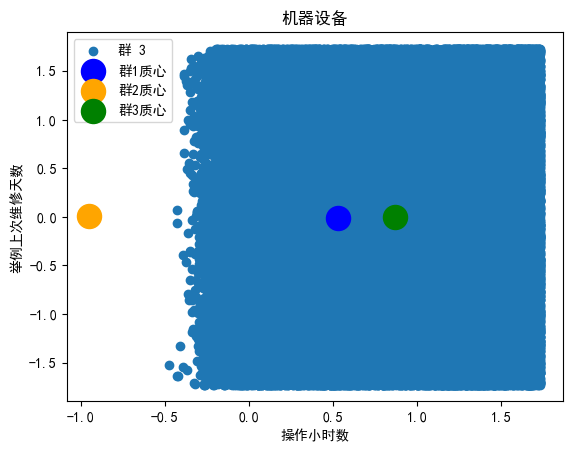

In [27]:
# 可视化结果
  #属于第一类的,数据第一列和数据第二列
# plt.scatter(scaled_data[clusters == 0, 0], scaled_data[clusters == 0, 7], label='群 1')
# plt.scatter(scaled_data[clusters == 1, 0], scaled_data[clusters == 1, 7], label='群 2')
plt.scatter(scaled_data[clusters == 2, 0], scaled_data[clusters == 2, 7], label='群 3')
# plt.scatter(scaled_data[clusters == 3, 0], scaled_data[clusters == 3, 7], label='群 4')
plt.scatter(kmeans.cluster_centers_[0, 0], kmeans.cluster_centers_[0, 7], s=300, c='blue', label='群1质心')
plt.scatter(kmeans.cluster_centers_[1, 0], kmeans.cluster_centers_[1, 7], s=300, c='orange', label='群2质心')
plt.scatter(kmeans.cluster_centers_[2, 0], kmeans.cluster_centers_[2, 7], s=300, c='green', label='群3质心')
# plt.scatter(kmeans.cluster_centers_[3, 0], kmeans.cluster_centers_[3, 7], s=300, c='red', label='群4质心')

plt.title('机器设备')
plt.xlabel('操作小时数')
plt.ylabel('举例上次维修天数')
plt.legend()
plt.show()

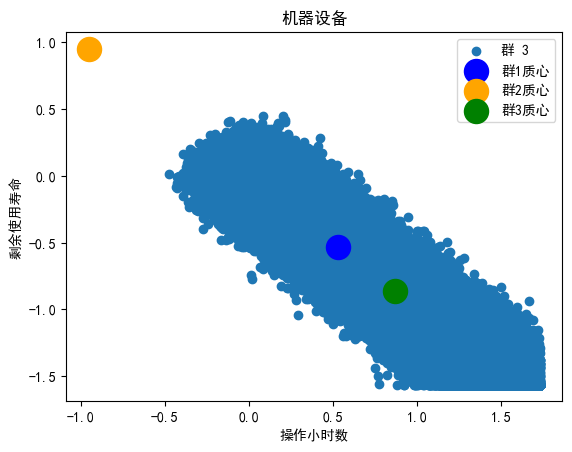

In [33]:
# 可视化结果
# plt.scatter(scaled_data[clusters == 0, 0], scaled_data[clusters == 0, 10], label='群 1')  #属于第一类的,数据第一列和数据第二列
# plt.scatter(scaled_data[clusters == 1, 0], scaled_data[clusters == 1, 10], label='群 2')
plt.scatter(scaled_data[clusters == 2, 0], scaled_data[clusters == 2, 10], label='群 3')
plt.scatter(kmeans.cluster_centers_[0, 0], kmeans.cluster_centers_[0, 10], s=300, c='blue', label='群1质心')
plt.scatter(kmeans.cluster_centers_[1, 0], kmeans.cluster_centers_[1, 10], s=300, c='orange', label='群2质心')
plt.scatter(kmeans.cluster_centers_[2, 0], kmeans.cluster_centers_[2, 10], s=300, c='green', label='群3质心')

plt.title('机器设备')
plt.xlabel('操作小时数')
plt.ylabel('剩余使用寿命')
plt.legend()
plt.show()